In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from src.data.utils.sparsity import build_ohlcv_sparsity_report

In [2]:
base_path = Path("../data/coinbase/ohlcv")

In [3]:
report = build_ohlcv_sparsity_report(
    base_path=base_path,
    # assets=["near-usdc"],
)

In [ ]:
filtered_report = report.filter(
    pl.col("availability") > 0.8
)
filtered_report.head(100)

asset,timeframe,range_start,range_end,files_processed,actual,expected,missing,availability,sparsity,gap_count,avg_gap_missing,shortest_gap_missing,largest_gap_missing,avg_extra_gap_seconds
str,str,"datetime[μs, UTC]","datetime[μs, UTC]",i64,i64,i64,i64,f64,f64,i64,f64,i64,i64,f64
"""aave-usdc""","""15m""",2020-12-15 17:00:00 UTC,2026-02-28 23:45:00 UTC,63,182373,182524,151,0.99,0.0,91,1.65,1,23,1493.4
"""aave-usdc""","""1d""",2020-12-15 00:00:00 UTC,2026-02-28 00:00:00 UTC,63,1902,1902,0,1.0,0.0,0,0.0,null,null,0.0
"""aave-usdc""","""1h""",2020-12-15 17:00:00 UTC,2026-02-28 23:00:00 UTC,63,45621,45631,10,0.99,0.0,2,5.0,5,5,18000.0
"""aave-usdc""","""1m""",2020-12-15 17:13:00 UTC,2026-02-28 23:58:00 UTC,63,2340634,2737846,397212,0.85,0.14,248978,1.59,1,361,95.72
"""aave-usdc""","""2h""",2020-12-15 16:00:00 UTC,2026-02-28 22:00:00 UTC,63,22812,22816,4,0.99,0.0,2,2.0,2,2,14400.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""comp-usdc""","""2h""",2020-06-23 16:00:00 UTC,2026-02-28 22:00:00 UTC,69,24912,24916,4,0.99,0.0,2,2.0,2,2,14400.0
"""comp-usdc""","""30m""",2020-06-23 16:30:00 UTC,2026-02-28 23:30:00 UTC,69,99544,99663,119,0.99,0.0,91,1.3,1,11,2353.84
"""comp-usdc""","""5m""",2020-06-23 16:30:00 UTC,2026-02-28 23:40:00 UTC,69,554681,597975,43294,0.92,0.07,32241,1.34,1,73,402.84


In [9]:
df = pl.read_parquet(f"{base_path}/near-usdc/1m/2026/01.parquet")

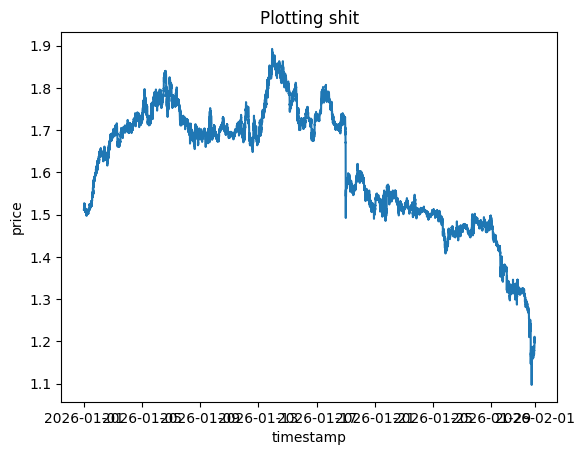

In [10]:
# Pass the timestamp series as X and the close series as Y
df = df.sort("timestamp")
plt.plot(df["timestamp"], df["close"])

plt.xlabel("timestamp")
plt.ylabel("price")
plt.title("Plotting shit")
plt.show()